#### 📌 Reading PNG Images in OpenCV

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

By default, cv2.imread() reads an image in BGR format. If the PNG image contains an alpha channel (transparency), the default behavior is to ignore that channel.

To preserve all channels, including the alpha channel, use cv2.IMREAD_UNCHANGED.

In [16]:
# Read PNG image (default)
img_butterfly_0 = cv2.imread("butterfly.png")
print("Shape:", img_butterfly_0.shape)

# Read PNG image with IMREAD_UNCHANGED
img_butterfly = cv2.imread("butterfly.png", cv2.IMREAD_UNCHANGED)
print("Shape with IMREAD_UNCHANGED:", img_butterfly.shape)

Shape: (1200, 1200, 3)
Shape with IMREAD_UNCHANGED: (1200, 1200, 4)


The first image has **3 channels (BGR)**, while the second image has **4 channels (BGRA)** because the transparency (alpha) channel is preserved.


---

#### 📌 Comparing PNG Images Before and After Color Conversion

First, let's display the images **without any color conversion**.

Since OpenCV reads images in **BGR/BGRA** format while Matplotlib expects **RGB/RGBA**, the displayed colors will look incorrect.


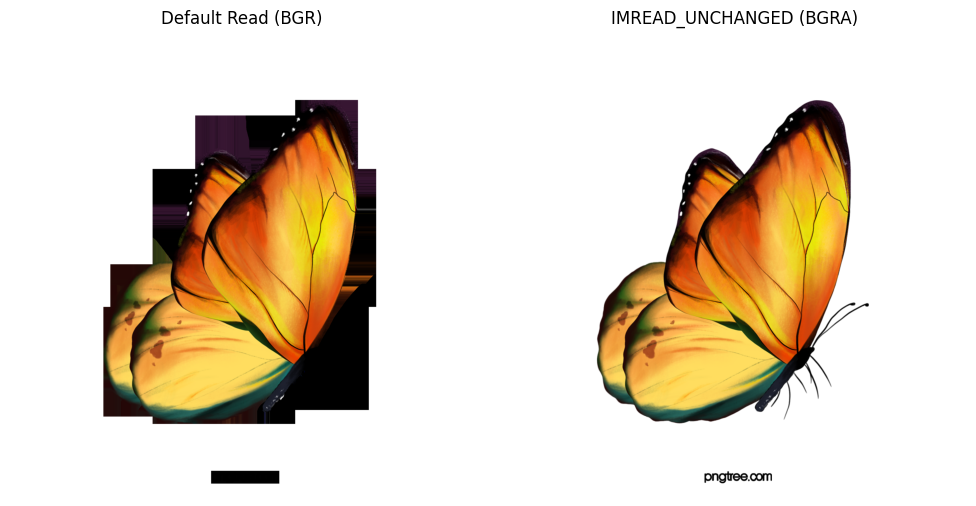

In [17]:
# Display images directly from OpenCV (before color conversion)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_butterfly_0)
plt.title("Default Read (BGR)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_butterfly)
plt.title("IMREAD_UNCHANGED (BGRA)")
plt.axis("off")

plt.tight_layout()
plt.show()


As you can see, the colors are not displayed correctly because Matplotlib assumes the images are in the RGB color space.

---

#### 📌 Convert BGR/BGRA to RGB/RGBA

To display the images correctly, convert the color space before using `imshow()`.

In [19]:
# Convert OpenCV color space to Matplotlib color space

img_butterfly_0_rgb = cv2.cvtColor(img_butterfly_0,cv2.COLOR_BGR2RGB)
img_butterfly_rgba = cv2.cvtColor(img_butterfly,cv2.COLOR_BGRA2RGBA)

#### 📌 Display Images After Color Conversion

Now the images are displayed with the correct colors.


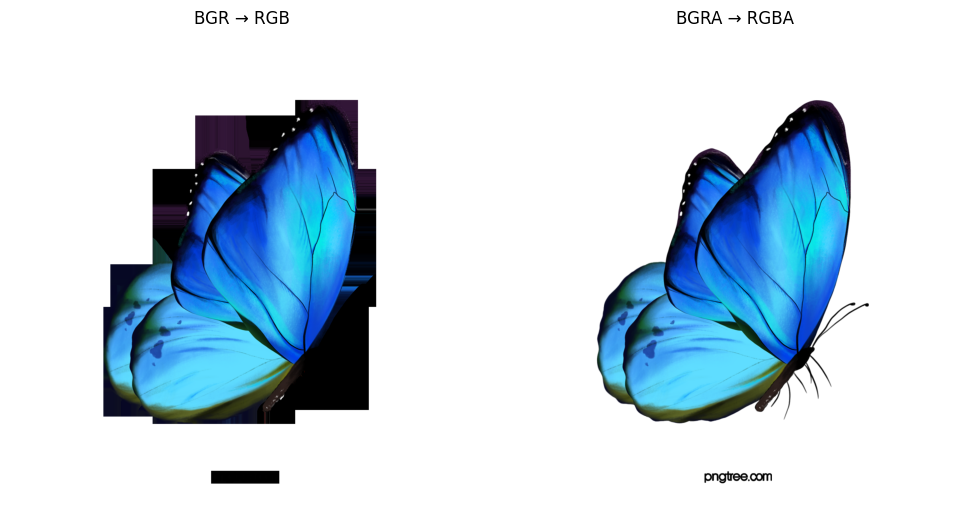

In [20]:

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_butterfly_0_rgb)
plt.title("BGR → RGB")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_butterfly_rgba)
plt.title("BGRA → RGBA")
plt.axis("off")

plt.tight_layout()
plt.show()

#### 📌 Separating the RGB and Alpha Channels

A PNG image read with `cv2.IMREAD_UNCHANGED` contains **4 channels (RGBA)**:

- **R** → Red
- **G** → Green
- **B** → Blue
- **A** → Alpha (Transparency)

Let's separate the RGB channels from the alpha channel.

In [33]:
img_butterfly_rgb = img_butterfly_rgba[:, :, :3]
img_butterfly_alpha = img_butterfly_rgba[:, :, 3]

Display both images:


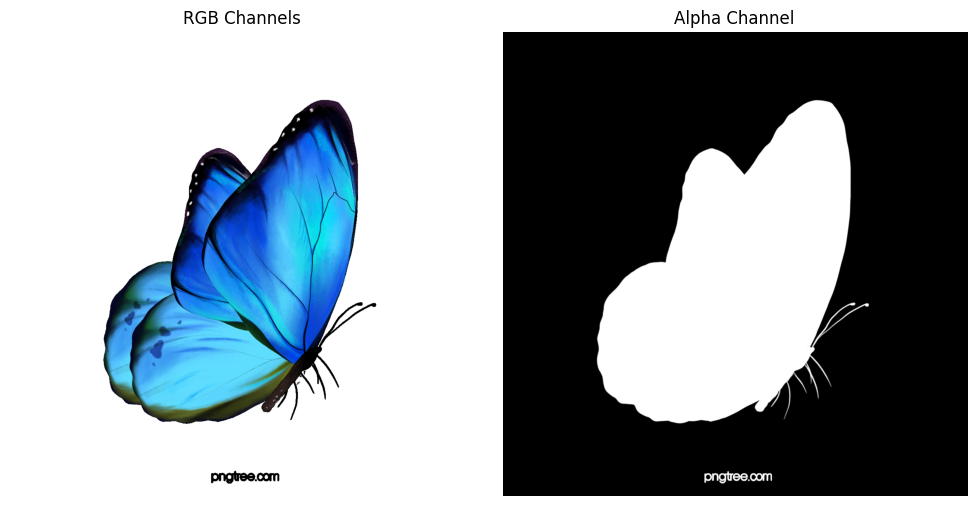

In [34]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_butterfly_rgb)
plt.title("RGB Channels")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_butterfly_alpha, cmap="gray")
plt.title("Alpha Channel")
plt.axis("off")

plt.tight_layout()
plt.show()


####  Observation

- The **RGB image** contains all color information AND with **some details info**.
- The **Alpha channel** controls the transparency of each pixel.
- White pixels (255) are fully visible.
- Black pixels (0) are completely transparent.

You can think of the alpha channel as a **transparency mask**.

#### 📌 Removing the Transparent Background

Using the alpha channel as a mask, we can replace all transparent pixels with a white background.

In [35]:
# Replace transparent pixels with white

img_butterfly_rgb[img_butterfly_alpha == 0] = 255


Display the updated RGB image.

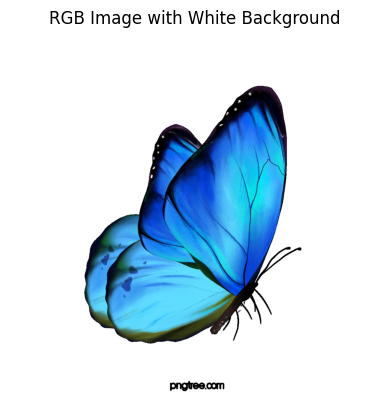

In [36]:
plt.imshow(img_butterfly_rgb)
plt.axis("off")
plt.title("RGB Image with White Background")
plt.show()

Now the transparent background has been replaced with white.


#### 📌 Merging the RGB and Alpha Channels

To reconstruct the original PNG image, we need to combine the RGB image and the alpha channel.

Since the RGB image has **3 channels** and the alpha image has **1 channel**, we cannot use `np.stack()` directly.

Instead, we use `np.dstack()`, which stacks arrays along the third dimension.

In [38]:
# Merge RGB and Alpha channels

new_img_butterfly = np.dstack([img_butterfly_rgb, img_butterfly_alpha])

Check the shape of the new image.


In [39]:
print("Shape of the new image:", new_img_butterfly.shape)


Shape of the new image: (1200, 1200, 4)


#### 📌 Saving the New PNG Image

The reconstructed image is currently in **RGBA** format.

However, OpenCV saves images in **BGRA** format.

Therefore, convert the image before saving.


In [40]:

# Convert RGBA → BGRA before saving

new_img_butterfly_bgra = cv2.cvtColor(new_img_butterfly,cv2.COLOR_RGBA2BGRA)

cv2.imwrite("newimage.png", new_img_butterfly_bgra)

True

✅ The new PNG image is now saved while preserving the transparency channel.
